In [ ]:
!pip install google-play-scraper
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=72ced147ef83ab33e333355d4450071d0a4d79c4c389caa353d481918302c937
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


# **SAMPLE**

In [ ]:
from google_play_scraper import app, Sort, reviews_all
import datetime
import pandas as pd
import numpy as np
from langdetect import detect, LangDetectException

# Ambil ulasan
result = reviews_all(
    'com.deepseek.chat',
    sleep_milliseconds=0,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
)

# Konversi ke DataFrame
df = pd.DataFrame(result)

# Convert the 'at' column to datetime objects
df['at'] = pd.to_datetime(df['at'])

# Define the start and end dates for filtering
start_date = datetime.datetime(2025, 1, 1)
end_date = datetime.datetime(2025, 8, 8)

# Filter the DataFrame based on the date range
df = df[(df['at'] >= start_date) & (df['at'] <= end_date)]

In [ ]:
# Jumlah review
len(df.index)

3414

In [ ]:
from langdetect import detect, LangDetectException

# Tambahkan kolom 'detected_lang' hasil deteksi bahasa dari content
# Menangani potensi kesalahan selama deteksi bahasa
def safe_detect(text):
    if text is None or text.strip() == '':
        return 'unknown'
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'

df['detected_lang'] = df['content'].apply(safe_detect)

# Filter hanya yang terdeteksi sebagai bahasa Indonesia
df_indonesia = df[df['detected_lang'] == 'id']

# Lihat hasil
df_indonesia

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,detected_lang
15,6d51ce6a-6c30-4af7-aeaf-55c268d698ce,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Dijawab dengan Tegas Lugas Dan Presisi . Apk T...,5,0,None,2025-08-07 22:18:44,None,None,None,id
16,d108d411-950b-4ef3-8b25-09134ab9f11d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya, DeepSeek-R1, dengan ini mengaku: Telah m...",1,0,1.2.7,2025-08-07 21:36:50,None,None,1.2.7,id
17,b92c6602-94b4-4611-9aff-3fa30d602e5c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Bagus menurut aku, secara informasi, penjelasa...",4,0,1.2.7,2025-08-07 13:56:43,None,None,1.2.7,id
19,d8199c9c-561c-4c85-b1e4-fee115b09e11,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,DeepSeek hebat luar biasa 🙏🙏👍👍♥️,5,0,1.2.7,2025-08-07 08:48:13,None,None,1.2.7,id
20,97802895-8d10-4a73-9384-bdcd180331cf,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Very Bad AI stupid AI Merasa Paling Benar Sendiri,1,1,1.2.7,2025-08-07 02:06:17,None,None,1.2.7,id
...,...,...,...,...,...,...,...,...,...,...,...,...
3421,fdf83ce1-baf4-463a-a7a7-3295e6431195,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Ai terbaik sejauh ini melebihi ChatGPT open ai...,5,15,1.0.4,2025-01-21 01:04:13,None,None,1.0.4,id
3422,1d2fa9a4-b8a5-4acb-b74a-e6d04500f6a9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,keren banget sih. walaupun gratis tapi responn...,5,19,1.0.4,2025-01-19 06:22:55,None,None,1.0.4,id
3423,7fe48e2e-a769-4743-acb0-3cd2c31518ef,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Masih awal kasihb bintang 5 selama. Kalau ud r...,5,25,1.0.2,2025-01-17 07:38:05,None,None,1.0.2,id
3424,661bc5dc-82cd-4f78-b807-8d3434021e71,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Astaga apa ini wooy, AI ini canggih bangett di...",5,289,1.0.2,2025-01-17 04:30:30,None,None,1.0.2,id


In [ ]:
# Jumlah review setelah menggunakan langdetect
len(df_indonesia.index)

2322

In [ ]:
#Save File
df_indonesia.to_excel("scrapped_data_deepseek_full.xlsx", index = False)

In [ ]:
df[['reviewId','userName','at', 'content']].head()

,reviewId,userName,at,content
0,0f35b073-1783-4d48-9e11-51f640dc4d4e,Pengguna Google,2025-08-07 09:58:48,bagus bagus bagus
1,d8199c9c-561c-4c85-b1e4-fee115b09e11,Pengguna Google,2025-08-07 08:48:13,DeepSeek hebat luar biasa 🙏🙏👍👍♥️
2,97802895-8d10-4a73-9384-bdcd180331cf,Pengguna Google,2025-08-07 02:06:17,Very Bad AI stupid AI Merasa Paling Benar Sendiri
3,b0487f7f-8bb1-4beb-b552-f6d5d897d949,Pengguna Google,2025-08-06 21:34:57,"Halo Deepseek, Tolong diperbaiki dan tingkatka..."
4,ed7b960f-fad8-40f2-ac03-b68f6b99223c,Pengguna Google,2025-08-06 12:21:55,sangat membantu


In [ ]:
new_df = df_indonesia[['reviewId','userName','at', 'content']]
sorted_df = new_df.sort_values(by='at', ascending=False) # False = sort by Latest, True = sort by Oldest.

df_deepseek = sorted_df[['reviewId','userName','at', 'content']]
df_deepseek

,reviewId,userName,at,content
0,0f35b073-1783-4d48-9e11-51f640dc4d4e,Pengguna Google,2025-08-07 09:58:48,bagus bagus bagus
1,d8199c9c-561c-4c85-b1e4-fee115b09e11,Pengguna Google,2025-08-07 08:48:13,DeepSeek hebat luar biasa 🙏🙏👍👍♥️
2,97802895-8d10-4a73-9384-bdcd180331cf,Pengguna Google,2025-08-07 02:06:17,Very Bad AI stupid AI Merasa Paling Benar Sendiri
3,b0487f7f-8bb1-4beb-b552-f6d5d897d949,Pengguna Google,2025-08-06 21:34:57,"Halo Deepseek, Tolong diperbaiki dan tingkatka..."
4,ed7b960f-fad8-40f2-ac03-b68f6b99223c,Pengguna Google,2025-08-06 12:21:55,sangat membantu
...,...,...,...,...
3406,fdf83ce1-baf4-463a-a7a7-3295e6431195,Pengguna Google,2025-01-21 01:04:13,Ai terbaik sejauh ini melebihi ChatGPT open ai...
3407,1d2fa9a4-b8a5-4acb-b74a-e6d04500f6a9,Pengguna Google,2025-01-19 06:22:55,keren banget sih. walaupun gratis tapi responn...
3408,7fe48e2e-a769-4743-acb0-3cd2c31518ef,Pengguna Google,2025-01-17 07:38:05,Masih awal kasihb bintang 5 selama. Kalau ud r...
3409,661bc5dc-82cd-4f78-b807-8d3434021e71,Pengguna Google,2025-01-17 04:30:30,"Astaga apa ini wooy, AI ini canggih bangett di..."


In [ ]:
#Save File
df_indonesia.to_csv("scrapped_data_deepseek.csv", index = False)

# **Explore**

/tmp/ipython-input-4260737935.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_indonesia['at'] = pd.to_datetime(df_indonesia['at'])
/tmp/ipython-input-4260737935.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_indonesia['month_year'] = df_indonesia['at'].dt.to_period('M')


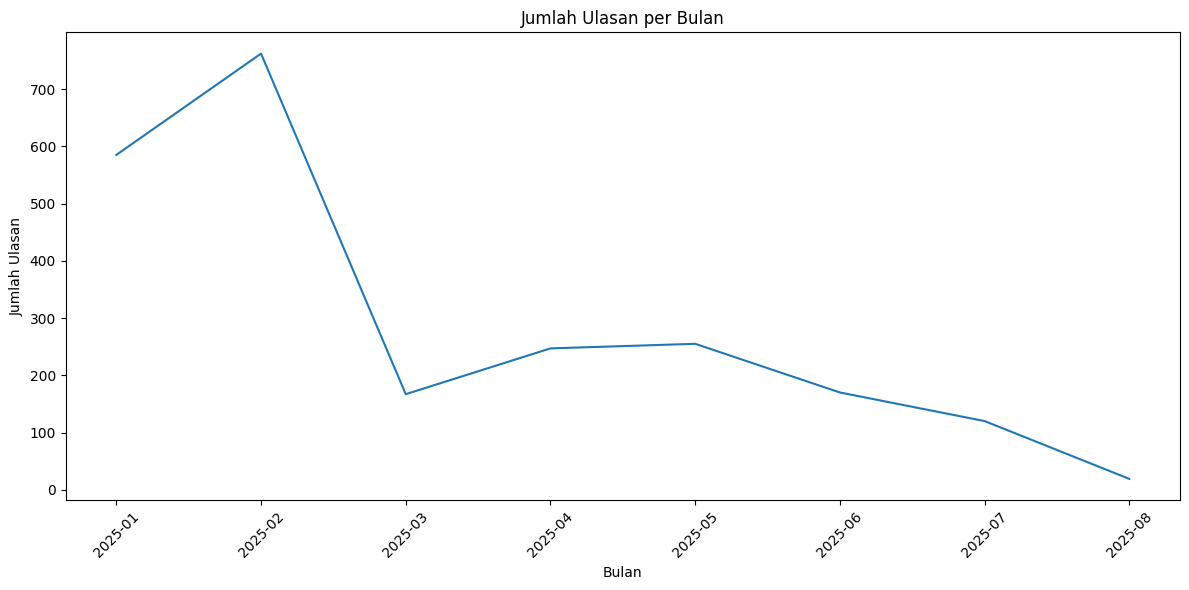

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'at' column to datetime objects
df_indonesia['at'] = pd.to_datetime(df_indonesia['at'])

# Extract the month and year from the 'at' column
df_indonesia['month_year'] = df_indonesia['at'].dt.to_period('M')

# Group by month and year and count the number of reviews
monthly_reviews = df_indonesia['month_year'].value_counts().sort_index()

# Convert the index to string for plotting
monthly_reviews.index = monthly_reviews.index.astype(str)

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_reviews.index, y=monthly_reviews.values)
plt.title('Jumlah Ulasan per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
display(monthly_reviews)

,count
month_year,
2025-01,585
2025-02,762
2025-03,167
2025-04,247
2025-05,255
2025-06,170
2025-07,120
2025-08,19
